In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from os.path import join
import torch
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from torchvision import transforms as T
sys.path.append("/n/home12/binxuwang/Github/Closed-loop-visual-insilico")
from core.model_load_utils import load_model_transform, MODEL_LAYER_FILTERS, LAYER_ABBREVIATION_MAPS
from neural_regress.sklearn_torchify_lib import SRP_torch, PCA_torch, LinearRegression_torch, SpatialAvg_torch
from circuit_toolkit.layer_hook_utils import featureFetcher_module, featureFetcher, get_module_names
from horama import maco, plot_maco
import sys
sys.path.append(r"/n/home12/binxuwang/Github/Closed-loop-visual-insilico")
from os.path import join
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from core.data_utils import load_neural_data, load_from_hdf5, load_neural_trial_resp_tensor, create_response_tensor
from core.posthoc_prediction_utils import parse_accentuated_filenames_to_df
from circuit_toolkit.plot_utils import saveallforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

outputroot = r"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models"
subject_id = "red_20250428-20250430"
modelname = "resnet50_robust"

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


In [ ]:
dataroot = r"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Ephys_Data"
data_path = join(dataroot, 'vvs-accentuate_controlsessions_5monkeys_250504-250512.h5')
data = load_from_hdf5(data_path)

In [2]:
import sys
sys.path.append(r"/n/home12/binxuwang/Github/Closed-loop-visual-insilico")
sys.path.append(r"/Users/binxuwang/Github/Closed-loop-visual-insilico/")
from os.path import join
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from core.data_utils import load_neural_data, load_from_hdf5, load_neural_trial_resp_tensor, create_response_tensor
from core.posthoc_prediction_utils import parse_accentuated_filenames_to_df

In [86]:
FIGDIR = "/n/home12/binxuwang/Github/Closed-loop-visual-insilico/export_dir/peer_review_export"

In [88]:
tabdir  = "/n/home12/binxuwang/Github/Closed-loop-visual-insilico/tables"
subject_id = "red_20250504-20250512"
df_accentuated = pd.read_pickle(join(tabdir, f"{subject_id}_202505_accentuated_df.pkl"))
df_accentuated["score"] = df_accentuated["score"].astype(float)
df_accentuated["neural_activation"] = df_accentuated["neural_activation"].astype(float)

In [6]:
df_accentuated

,model_name,unit_id,img_id,level,score,filepath,neural_activation
0,AlexNet_training_seed_01,0,0,-0.228237,-0.221289,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.431920
1,AlexNet_training_seed_01,0,0,-1.037346,-1.027856,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.398581
2,AlexNet_training_seed_01,0,0,-1.846455,-1.838532,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,1.373433
3,AlexNet_training_seed_01,0,0,0.580873,0.572135,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.567470
4,AlexNet_training_seed_01,0,0,1.389982,1.380919,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.260936
...,...,...,...,...,...,...,...
5569,siglip2_vitb16,9,9,2.701443,2.691693,siglip2_vitb16_RidgeCV_unit_9_img_9_level_2.70...,-0.145980
5570,siglip2_vitb16,9,9,3.442825,3.434636,siglip2_vitb16_RidgeCV_unit_9_img_9_level_3.44...,0.876949
5571,siglip2_vitb16,9,9,4.184206,4.180340,siglip2_vitb16_RidgeCV_unit_9_img_9_level_4.18...,0.449348
5572,siglip2_vitb16,9,9,4.925587,4.921776,siglip2_vitb16_RidgeCV_unit_9_img_9_level_4.92...,-0.821746


In [7]:
dataroot = r"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Ephys_Data"
data_path = join(dataroot, 'vvs-accentuate_controlsessions_5monkeys_250504-250512.h5')
data = load_from_hdf5(data_path)

In [8]:
subject_id = 'red_20250504-20250512'
# subject_id = "paul_20250505-20250512"
respmat = data[subject_id]["repavg"]['response_peak']
stimnames = data[subject_id]["repavg"]["stimulus_name"]
print("respmat.shape", respmat.shape)
print("stimnames.shape", stimnames.shape)
stimnames_str = [s.decode('utf-8') for s in stimnames]
df_allstim = parse_accentuated_filenames_to_df(stimnames_str, include_parse_fail=True)

respmat.shape (5575, 64)
stimnames.shape (5575,)


In [9]:
unit_list = df_allstim.unit_id.dropna().unique()
df_allstim_w_neural_rsp = df_allstim.copy()
for unit in unit_list:
    df_allstim_w_neural_rsp[f"neural_resp_unit_{unit}"] = respmat[:, unit]

In [10]:
df_allstim_w_neural_rsp

,model_name,unit_id,img_id,level,score,filepath,neural_resp_unit_0,neural_resp_unit_15,neural_resp_unit_19,neural_resp_unit_2,neural_resp_unit_9
0,AlexNet_training_seed_01,0,0,-0.228237,-0.221289,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.431920,0.577541,3.035172,-0.023871,0.651321
1,AlexNet_training_seed_01,0,0,-1.037346,-1.027856,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.398581,0.128980,0.901974,0.836844,0.723255
2,AlexNet_training_seed_01,0,0,-1.846455,-1.838532,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,1.373433,3.106471,1.747782,0.639093,2.562169
3,AlexNet_training_seed_01,0,0,0.580873,0.572135,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.567470,1.383990,5.369764,-0.143638,1.097371
4,AlexNet_training_seed_01,0,0,1.389982,1.380919,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...,0.260936,1.754026,3.460443,-0.072539,1.246995
...,...,...,...,...,...,...,...,...,...,...,...
5570,siglip2_vitb16,9,9,3.442825,3.434636,siglip2_vitb16_RidgeCV_unit_9_img_9_level_3.44...,0.549185,-0.649754,-0.206392,-0.292614,0.876949
5571,siglip2_vitb16,9,9,4.184206,4.18034,siglip2_vitb16_RidgeCV_unit_9_img_9_level_4.18...,1.054193,-0.487268,-0.099224,-0.217041,0.449348
5572,siglip2_vitb16,9,9,4.925587,4.921776,siglip2_vitb16_RidgeCV_unit_9_img_9_level_4.92...,-0.582650,-0.295747,-0.890730,-0.673369,-0.821746
5573,siglip2_vitb16,9,9,5.666968,5.657128,siglip2_vitb16_RidgeCV_unit_9_img_9_level_5.66...,-0.861819,-0.032162,0.236117,-0.510662,-0.055597


In [11]:
df_natimg_w_neural_rsp = df_allstim_w_neural_rsp.query("model_name.isna()")
df_natimg_w_neural_rsp = df_natimg_w_neural_rsp.drop(columns=['model_name', 'unit_id', 'img_id', 'level', 'score'])

In [12]:
df_natimg_w_neural_rsp

,filepath,neural_resp_unit_0,neural_resp_unit_15,neural_resp_unit_19,neural_resp_unit_2,neural_resp_unit_9
546,FFM_119.png,0.148070,0.711617,0.094558,1.013245,0.663447
547,FH_148.png,-0.254753,1.568507,-0.248642,0.569861,0.267570
548,FH_181.png,1.311378,2.605409,1.026851,-0.053576,1.877442
549,FH_219.png,-0.146456,3.109067,-0.154859,0.419178,0.443306
550,FH_226.png,5.138379,4.219829,3.595835,-0.218638,5.259384
...,...,...,...,...,...,...
5023,shared0934_nsd67743.png,0.445123,0.350200,0.301542,-0.145756,0.713468
5024,shared0940_nsd68312.png,-0.072270,0.237377,-0.369267,-0.398229,-0.168178
5025,shared0968_nsd70194.png,0.245177,0.925741,-0.300647,0.260764,0.136593
5026,shared0998_nsd72606.png,-0.468078,-0.592207,-0.804196,-0.404909,-0.576689


In [30]:
subject_id = "red_20250428-20250430"
posthoc_dir = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}/posthoc_model_predict"
df_encoding_w_pred_resp = pd.read_pickle(join(posthoc_dir, f"encoding_stim_info_w_pred_resp_{subject_id}.pkl"))

In [31]:
df_encoding_w_pred_resp

,stimulus_name,is_nsd,is_floc,is_OO,is_train,is_normalizer,is_test,image_fps,pred_resp_AlexNet_training_seed_01_unit_0,pred_resp_AlexNet_training_seed_01_unit_15,...,pred_resp_resnet50_robust_unit_0,pred_resp_resnet50_robust_unit_15,pred_resp_resnet50_robust_unit_19,pred_resp_resnet50_robust_unit_2,pred_resp_resnet50_robust_unit_9,pred_resp_siglip2_vitb16_unit_0,pred_resp_siglip2_vitb16_unit_15,pred_resp_siglip2_vitb16_unit_19,pred_resp_siglip2_vitb16_unit_2,pred_resp_siglip2_vitb16_unit_9
0,BigAnimate_20.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,-0.151740,-0.672605,...,-0.238290,-0.529224,-0.342366,-0.672722,-0.150674,-0.230840,-0.595648,-0.317637,-0.505491,-0.150998
1,BigAnimate_60.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,0.090289,-0.327171,...,-0.076855,-0.432661,-0.324526,-0.177651,-0.195175,0.040841,-0.433597,-0.283307,-0.261162,-0.152137
2,FFM_022.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,0.453049,0.727893,...,0.331854,0.813201,0.438944,0.143470,0.582507,0.390424,0.719016,0.510035,0.109263,0.630329
3,FFM_030.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,-0.068378,0.515165,...,0.061748,0.641946,0.019931,-0.255895,0.014679,-0.053412,0.564646,-0.093356,-0.152845,-0.058448
4,FFM_037.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,0.221000,0.352040,...,0.212286,0.358183,-0.155264,0.411841,0.086989,0.138923,0.527494,-0.284060,0.484491,-0.032686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964,toyhorse_15.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,-0.101748,-0.492069,...,-0.177696,-0.505669,-0.528427,0.075982,-0.333016,-0.228496,-0.442947,-0.469842,0.062032,-0.296735
965,vase_07.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,1.068220,0.104162,...,0.700098,-0.493550,0.264510,-0.506453,0.361253,0.560097,-0.558275,0.175673,-0.428007,0.297392
966,wineglass_13.png,False,False,True,True,False,False,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,0.483790,-0.034035,...,0.365427,-0.502787,0.007602,-0.509526,-0.077331,0.119051,-0.480460,-0.039459,-0.572218,-0.130211
967,yarn_03.png,False,False,True,False,False,True,/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuat...,0.032516,-0.009379,...,-0.429722,-0.306796,-0.392040,-0.215662,-0.344712,-0.334517,-0.250217,-0.586871,-0.270701,-0.619806


In [32]:
df_merged = pd.merge(
    df_natimg_w_neural_rsp, 
    df_encoding_w_pred_resp, 
    how="inner", 
    left_on="filepath", 
    right_on="stimulus_name", 
    # suffixes=["_neural", "_encoding"]
)
df_merged

,filepath,neural_resp_unit_0,neural_resp_unit_15,neural_resp_unit_19,neural_resp_unit_2,neural_resp_unit_9,stimulus_name,is_nsd,is_floc,is_OO,...,pred_resp_resnet50_robust_unit_0,pred_resp_resnet50_robust_unit_15,pred_resp_resnet50_robust_unit_19,pred_resp_resnet50_robust_unit_2,pred_resp_resnet50_robust_unit_9,pred_resp_siglip2_vitb16_unit_0,pred_resp_siglip2_vitb16_unit_15,pred_resp_siglip2_vitb16_unit_19,pred_resp_siglip2_vitb16_unit_2,pred_resp_siglip2_vitb16_unit_9
0,FFM_119.png,0.148070,0.711617,0.094558,1.013245,0.663447,FFM_119.png,False,False,True,...,-0.042399,0.376466,0.032345,0.397198,0.085758,-0.118549,0.345718,0.000321,0.335533,0.061999
1,FH_148.png,-0.254753,1.568507,-0.248642,0.569861,0.267570,FH_148.png,False,False,True,...,0.197866,0.768324,0.078088,0.481381,0.290228,0.112273,1.094218,0.075358,0.311867,0.360632
2,FH_181.png,1.311378,2.605409,1.026851,-0.053576,1.877442,FH_181.png,False,False,True,...,0.813520,0.683299,0.658772,0.708489,1.134469,1.840859,1.260378,1.627213,1.003707,2.089359
3,FH_219.png,-0.146456,3.109067,-0.154859,0.419178,0.443306,FH_219.png,False,False,True,...,0.134116,2.229799,-0.074492,0.426779,0.383144,-0.008517,2.428303,-0.137647,0.406842,0.324738
4,FH_226.png,5.138379,4.219829,3.595835,-0.218638,5.259384,FH_226.png,False,False,True,...,2.365682,2.137363,2.261666,0.066455,2.764836,2.634869,2.282684,2.278650,0.162379,2.893975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,shared0934_nsd67743.png,0.445123,0.350200,0.301542,-0.145756,0.713468,shared0934_nsd67743.png,True,False,False,...,0.774862,0.565059,0.759908,1.325189,0.588232,0.033293,0.140401,0.145394,0.778138,0.061406
96,shared0940_nsd68312.png,-0.072270,0.237377,-0.369267,-0.398229,-0.168178,shared0940_nsd68312.png,True,False,False,...,0.307060,0.333852,-0.047081,0.113325,-0.061528,-0.087165,-0.054316,0.029104,0.044719,0.039929
97,shared0968_nsd70194.png,0.245177,0.925741,-0.300647,0.260764,0.136593,shared0968_nsd70194.png,True,False,False,...,0.131851,0.486378,0.273780,1.073357,0.260224,0.155770,0.530142,0.177394,0.879394,0.198146
98,shared0998_nsd72606.png,-0.468078,-0.592207,-0.804196,-0.404909,-0.576689,shared0998_nsd72606.png,True,False,False,...,-0.421312,-0.748704,-0.298905,-0.274826,-0.102357,-0.409150,-0.765045,-0.256893,-0.303167,-0.057417


In [35]:
df_merged.is_nsd

0     False
1     False
2     False
3     False
4     False
      ...  
95     True
96     True
97     True
98     True
99    False
Name: is_nsd, Length: 100, dtype: bool

In [36]:
df_merged['is_test'] = (
    df_merged['is_test']
    .replace({1: True, 0: False, '1': True, '0': False, 'True': True, 'False': False})
    .astype(bool)
)

/tmp/ipykernel_1606480/4157577185.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({1: True, 0: False, '1': True, '0': False, 'True': True, 'False': False})


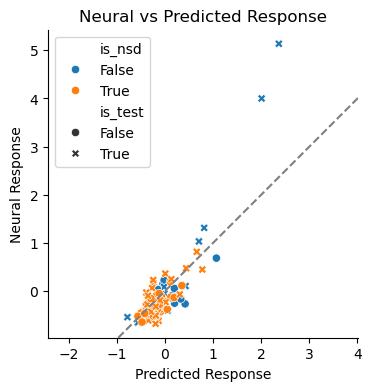

In [41]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_merged, y='neural_resp_unit_0', x='pred_resp_resnet50_robust_unit_0',
                style='is_test',hue='is_nsd')
# Draw a simple y=x reference line using ax
ax = plt.gca()
ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
curr_xlim = ax.get_xlim()
curr_ylim = ax.get_ylim()
min_val = min(curr_xlim[0], curr_ylim[0])
max_val = max(curr_xlim[1], curr_ylim[1])
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
plt.axis('equal')
plt.xlabel('Predicted Response')
plt.ylabel('Neural Response')
plt.title('Neural vs Predicted Response')
plt.show()


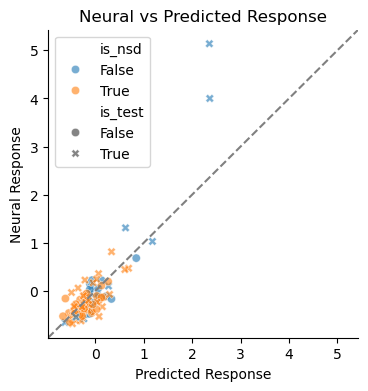

In [43]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_merged, y='neural_resp_unit_0', x='pred_resp_resnet50_unit_0',
                style='is_test', hue='is_nsd', alpha=0.6)
# Draw a simple y=x reference line using ax
ax = plt.gca()
curr_xlim = ax.get_xlim()
curr_ylim = ax.get_ylim()
min_val = min(curr_xlim[0], curr_ylim[0])
max_val = max(curr_xlim[1], curr_ylim[1])
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
plt.xlabel('Predicted Response')
plt.ylabel('Neural Response')
plt.title('Neural vs Predicted Response')
plt.show()


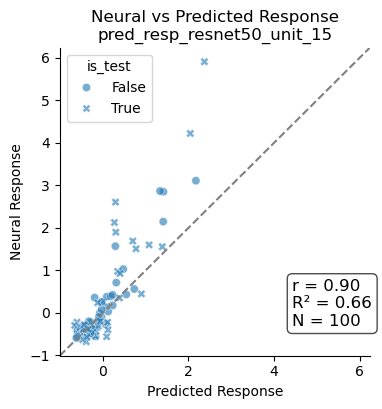

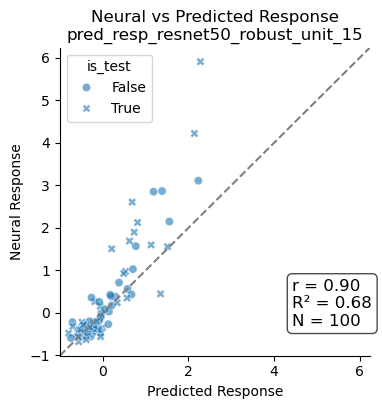

In [89]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
unit_id = 15
yvar = f'neural_resp_unit_{unit_id}'
for reviewer in ['resnet50', 'resnet50_robust']:
    xvar = f'pred_resp_{reviewer}_unit_{unit_id}'
    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=df_merged, y=yvar, x=xvar,
                    style='is_test', alpha=0.6)
    # Compute correlation and R2, using dropna for fair computation
    x = df_merged[xvar]
    y = df_merged[yvar]
    mask = x.notna() & y.notna()
    corr, _ = pearsonr(x[mask], y[mask])
    r2 = r2_score(y[mask], x[mask])
    annot_txt = f"r = {corr:.2f}\nR² = {r2:.2f}\nN = {mask.sum()}"
    # Draw a simple y=x reference line using ax
    ax = plt.gca()
    curr_xlim = ax.get_xlim()
    curr_ylim = ax.get_ylim()
    min_val = min(curr_xlim[0], curr_ylim[0])
    max_val = max(curr_xlim[1], curr_ylim[1])
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
    # Annotate statistics in upper left of plot window
    ax.text(0.75, 0.25, annot_txt, transform=ax.transAxes, ha='left', va='top',
            fontsize=12, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
    plt.xlabel('Predicted Response')
    plt.ylabel('Neural Response')
    plt.title(f'Neural vs Predicted Response\n{xvar}')
    saveallforms(FIGDIR, f"acc_peer_review_{subject_id}_U{unit_id}_NSD_images_rev_{reviewer}")
    plt.show()

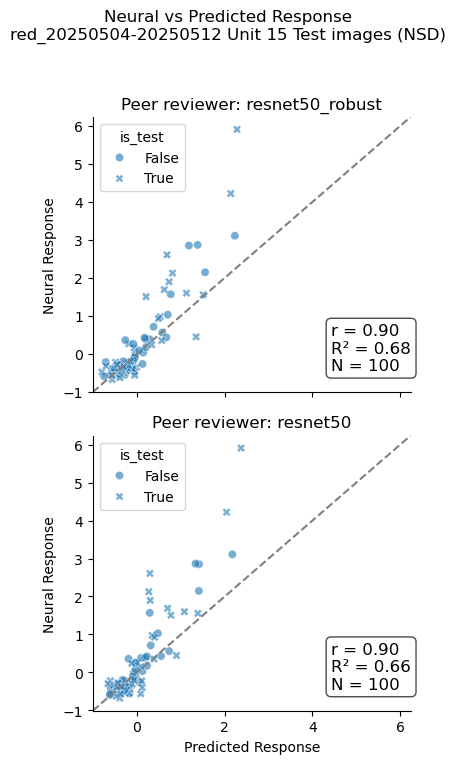

In [100]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

unit_id = 15
yvar = f'neural_resp_unit_{unit_id}'
reviewers = ['resnet50_robust', 'resnet50', ]
n_panels = len(reviewers)

fig, axes = plt.subplots(n_panels, 1, figsize=(4, 8), sharex=True, sharey=True)
if n_panels == 1:
    axes = [axes]  # ensure axes is always iterable

for idx, reviewer in enumerate(reviewers):
    xvar = f'pred_resp_{reviewer}_unit_{unit_id}'
    ax = axes[idx]
    sns.scatterplot(data=df_merged, y=yvar, x=xvar,
                    style='is_test', alpha=0.6, ax=ax)
    # Compute correlation and R2, using dropna for fair computation
    x = df_merged[xvar]
    y = df_merged[yvar]
    mask = x.notna() & y.notna()
    corr, _ = pearsonr(x[mask], y[mask])
    r2 = r2_score(y[mask], x[mask])
    annot_txt = f"r = {corr:.2f}\nR² = {r2:.2f}\nN = {mask.sum()}"
    # Set tight x/y lims for both panels
    curr_xlim = ax.get_xlim()
    curr_ylim = ax.get_ylim()
    min_val = min(curr_xlim[0], curr_ylim[0])
    max_val = max(curr_xlim[1], curr_ylim[1])
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
    # Annotate statistics in upper left of panel
    ax.text(0.75, 0.25, annot_txt, transform=ax.transAxes, ha='left', va='top',
            fontsize=12, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
    ax.set_xlabel('Predicted Response')
    ax.set_ylabel('Neural Response')
    ax.set_title(f"Peer reviewer: {reviewer}")

fig.suptitle(f'Neural vs Predicted Response\n{subject_id} Unit {unit_id} Test images (NSD)')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
saveallforms(FIGDIR, f"acc_peer_review_{subject_id}_U{unit_id}_NSD_images_topbot")
plt.show()

In [ ]:
unit_acc_df = df_allstim_w_neural_rsp.query("model_name == 'resnet50_robust' and unit_id == 0")


,model_name,unit_id,img_id,level,score,filepath,neural_resp_unit_0,neural_resp_unit_15,neural_resp_unit_19,neural_resp_unit_2,neural_resp_unit_9
4412,resnet50_robust,0,0,-0.228237,-0.219963,resnet50_robust_RidgeCV_unit_0_img_0_level_-0....,0.030153,0.727059,0.129424,-0.419502,-0.523040
4413,resnet50_robust,0,0,-1.037346,-1.029176,resnet50_robust_RidgeCV_unit_0_img_0_level_-1....,-0.245621,0.113512,-0.679929,-0.390131,-0.441482
4414,resnet50_robust,0,0,-1.846455,-1.836622,resnet50_robust_RidgeCV_unit_0_img_0_level_-1....,-0.788166,-0.636989,-1.120392,-0.475348,0.012605
4415,resnet50_robust,0,0,0.580873,0.589899,resnet50_robust_RidgeCV_unit_0_img_0_level_0.5...,1.235810,1.520630,5.168961,1.136872,1.190189
4416,resnet50_robust,0,0,1.389982,1.380332,resnet50_robust_RidgeCV_unit_0_img_0_level_1.3...,1.306203,1.167917,1.364896,0.413827,1.318440
...,...,...,...,...,...,...,...,...,...,...,...
4516,resnet50_robust,0,9,3.0082,2.998513,resnet50_robust_RidgeCV_unit_0_img_9_level_3.0...,0.606543,-0.712249,0.244553,-0.298186,0.990901
4517,resnet50_robust,0,9,3.817309,3.807415,resnet50_robust_RidgeCV_unit_0_img_9_level_3.8...,1.523036,0.058862,0.462135,0.144185,0.587221
4518,resnet50_robust,0,9,4.626418,4.310103,resnet50_robust_RidgeCV_unit_0_img_9_level_4.6...,-0.360303,0.899821,0.145618,0.704657,0.093536
4519,resnet50_robust,0,9,5.435527,4.282414,resnet50_robust_RidgeCV_unit_0_img_9_level_5.4...,0.483582,-0.222041,0.354013,0.607286,0.398092


### Accentuated 

In [52]:
import pickle as pkl
encoding_rootdir = r"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models"
encoding_subject_id = "red_20250428-20250430"
accentuated_stim_info_w_pred_resp_path = f"{encoding_rootdir}/{encoding_subject_id}/posthoc_model_predict/accentuated_stim_info_w_pred_resp_{encoding_subject_id}.pkl"
accentuated_stim_info_w_pred_resp = pkl.load(open(accentuated_stim_info_w_pred_resp_path, "rb"))
accentuated_stim_info_w_pred_resp

/tmp/ipykernel_1606480/902432555.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  accentuated_stim_info_w_pred_resp = pkl.load(open(accentuated_stim_info_w_pred_resp_path, "rb"))


,model_name,unit_id,img_id,level,score,filepath,pred_resp_AlexNet_training_seed_01_unit_0,pred_resp_AlexNet_training_seed_01_unit_15,pred_resp_AlexNet_training_seed_01_unit_19,pred_resp_AlexNet_training_seed_01_unit_2,...,pred_resp_resnet50_robust_unit_0,pred_resp_resnet50_robust_unit_15,pred_resp_resnet50_robust_unit_19,pred_resp_resnet50_robust_unit_2,pred_resp_resnet50_robust_unit_9,pred_resp_siglip2_vitb16_unit_0,pred_resp_siglip2_vitb16_unit_15,pred_resp_siglip2_vitb16_unit_19,pred_resp_siglip2_vitb16_unit_2,pred_resp_siglip2_vitb16_unit_9
0,AlexNet_training_seed_01,0,0,-0.228237,-0.221289,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,-0.215352,-0.048412,-0.032983,0.312984,...,0.678680,0.822875,1.137569,1.059690,1.138820,0.177207,0.327468,0.359148,0.677599,0.348708
1,AlexNet_training_seed_01,0,0,-1.037346,-1.027856,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,-1.030597,-0.547346,-0.718770,0.264506,...,0.666396,0.790431,1.157040,1.017175,1.147675,0.297980,0.394564,0.400089,0.560250,0.432954
2,AlexNet_training_seed_01,0,0,-1.846455,-1.838532,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,-1.840062,-1.077613,-1.406070,0.208471,...,0.626149,0.732566,1.169050,0.938542,1.145592,0.301777,0.365760,0.453462,0.503688,0.471211
3,AlexNet_training_seed_01,0,0,0.580873,0.572135,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.580558,0.408522,0.621783,0.270804,...,0.664914,0.816001,1.122917,1.029036,1.127711,0.121254,0.343337,0.375945,0.712595,0.344175
4,AlexNet_training_seed_01,0,0,1.389982,1.380919,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,1.389751,0.828179,1.236538,0.221984,...,0.650314,0.816000,1.163512,0.985825,1.166690,0.219089,0.379959,0.363606,0.496675,0.362347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,siglip2_vitb16,9,9,2.701443,2.691693,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.675457,0.179394,0.570379,-0.125893,...,0.408323,0.443555,0.057397,0.191934,0.037918,2.072134,1.186616,2.423980,0.319658,2.686192
5496,siglip2_vitb16,9,9,3.442825,3.434636,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.496783,0.132663,0.397479,-0.125035,...,0.405369,0.433399,0.042641,0.194160,0.029552,2.505370,1.492182,3.184868,0.360922,3.430079
5497,siglip2_vitb16,9,9,4.184206,4.180340,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.514549,0.225759,0.436111,-0.121330,...,0.413317,0.419002,0.027742,0.201799,0.020518,2.701764,1.564144,3.877917,0.409598,4.169995
5498,siglip2_vitb16,9,9,4.925587,4.921776,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.305701,-0.034255,0.171149,-0.112103,...,0.370868,0.370514,-0.012873,0.205893,-0.012511,3.149135,1.826766,4.706793,0.256107,4.929672


In [53]:
import os
accentuated_stim_info_w_pred_resp['basename'] = accentuated_stim_info_w_pred_resp['filepath'].apply(os.path.basename)
accentuated_stim_info_w_pred_resp

,model_name,unit_id,img_id,level,score,filepath,pred_resp_AlexNet_training_seed_01_unit_0,pred_resp_AlexNet_training_seed_01_unit_15,pred_resp_AlexNet_training_seed_01_unit_19,pred_resp_AlexNet_training_seed_01_unit_2,...,pred_resp_resnet50_robust_unit_15,pred_resp_resnet50_robust_unit_19,pred_resp_resnet50_robust_unit_2,pred_resp_resnet50_robust_unit_9,pred_resp_siglip2_vitb16_unit_0,pred_resp_siglip2_vitb16_unit_15,pred_resp_siglip2_vitb16_unit_19,pred_resp_siglip2_vitb16_unit_2,pred_resp_siglip2_vitb16_unit_9,basename
0,AlexNet_training_seed_01,0,0,-0.228237,-0.221289,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,-0.215352,-0.048412,-0.032983,0.312984,...,0.822875,1.137569,1.059690,1.138820,0.177207,0.327468,0.359148,0.677599,0.348708,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...
1,AlexNet_training_seed_01,0,0,-1.037346,-1.027856,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,-1.030597,-0.547346,-0.718770,0.264506,...,0.790431,1.157040,1.017175,1.147675,0.297980,0.394564,0.400089,0.560250,0.432954,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...
2,AlexNet_training_seed_01,0,0,-1.846455,-1.838532,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,-1.840062,-1.077613,-1.406070,0.208471,...,0.732566,1.169050,0.938542,1.145592,0.301777,0.365760,0.453462,0.503688,0.471211,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...
3,AlexNet_training_seed_01,0,0,0.580873,0.572135,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.580558,0.408522,0.621783,0.270804,...,0.816001,1.122917,1.029036,1.127711,0.121254,0.343337,0.375945,0.712595,0.344175,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...
4,AlexNet_training_seed_01,0,0,1.389982,1.380919,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,1.389751,0.828179,1.236538,0.221984,...,0.816000,1.163512,0.985825,1.166690,0.219089,0.379959,0.363606,0.496675,0.362347,AlexNet_training_seed_01_RidgeCV_unit_0_img_0_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,siglip2_vitb16,9,9,2.701443,2.691693,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.675457,0.179394,0.570379,-0.125893,...,0.443555,0.057397,0.191934,0.037918,2.072134,1.186616,2.423980,0.319658,2.686192,siglip2_vitb16_RidgeCV_unit_9_img_9_level_2.70...
5496,siglip2_vitb16,9,9,3.442825,3.434636,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.496783,0.132663,0.397479,-0.125035,...,0.433399,0.042641,0.194160,0.029552,2.505370,1.492182,3.184868,0.360922,3.430079,siglip2_vitb16_RidgeCV_unit_9_img_9_level_3.44...
5497,siglip2_vitb16,9,9,4.184206,4.180340,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.514549,0.225759,0.436111,-0.121330,...,0.419002,0.027742,0.201799,0.020518,2.701764,1.564144,3.877917,0.409598,4.169995,siglip2_vitb16_RidgeCV_unit_9_img_9_level_4.18...
5498,siglip2_vitb16,9,9,4.925587,4.921776,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...,0.305701,-0.034255,0.171149,-0.112103,...,0.370514,-0.012873,0.205893,-0.012511,3.149135,1.826766,4.706793,0.256107,4.929672,siglip2_vitb16_RidgeCV_unit_9_img_9_level_4.92...


In [70]:
# Merge accentuated_stim_info_w_pred_resp and df_allstim based on matching 'basename' and 'filepath'
# Ensure that 'level', 'img_id', 'score', 'unit_id', 'model_name' come from df_allstim for the matching entry
merge_keys_left = ['basename', 'img_id', 'unit_id', 'model_name']
merge_keys_right = ['filepath', 'img_id', 'unit_id', 'model_name']
# Do a left merge: only keep rows in accentuated_stim_info_w_pred_resp that match df_allstim by 'basename' <-> 'filepath'
accentuated_merged_df = accentuated_stim_info_w_pred_resp.merge(
    df_allstim_w_neural_rsp,
    left_on=merge_keys_left, right_on=merge_keys_right,
    how='inner', suffixes=('', '_dfallstim')
)
assert np.allclose(
    accentuated_merged_df['score'],
    accentuated_merged_df['score_dfallstim'].astype(float),
    atol=1e-6,
    equal_nan=True,
)
assert np.allclose(
    accentuated_merged_df['level'],
    accentuated_merged_df['level_dfallstim'].astype(float),
    atol=1e-6,
    equal_nan=True,
)

In [80]:
accentuated_merged_df.unit_id.unique()

array([0, 15, 19, 2, 9], dtype=object)

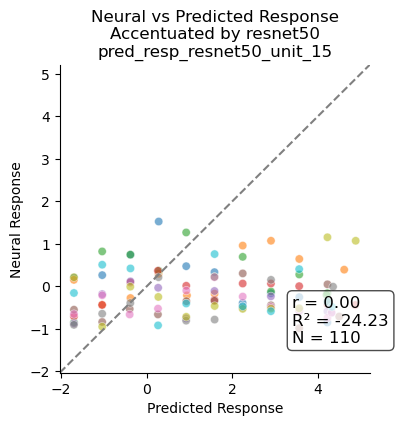

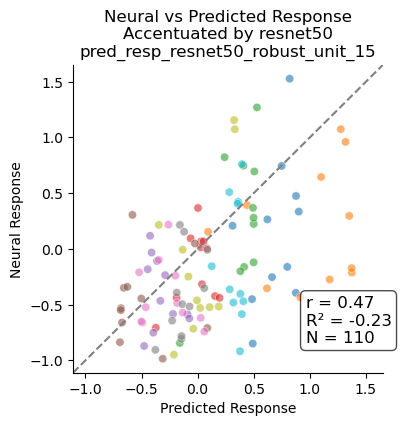

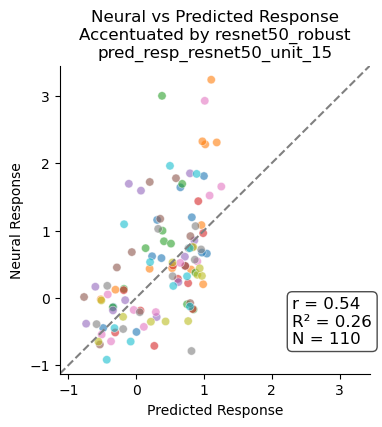

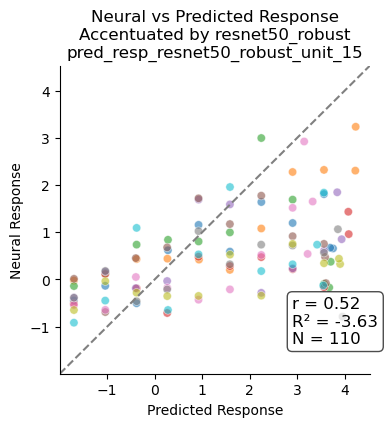

In [90]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
unit_id = 15
yvar = f'neural_resp_unit_{unit_id}'
for accentuators in ['resnet50', 'resnet50_robust']:
    unit_acc_df = accentuated_merged_df.query("model_name == @accentuators and unit_id == @unit_id")
    for reviewer in ['resnet50', 'resnet50_robust']:
        xvar = f'pred_resp_{reviewer}_unit_{unit_id}'
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=unit_acc_df, y=yvar, x=xvar,
                        hue='img_id', alpha=0.6, palette='tab10', legend=False)
        # Compute correlation and R2, using dropna for fair computation
        x = unit_acc_df[xvar]
        y = unit_acc_df[yvar]
        mask = x.notna() & y.notna()
        corr, _ = pearsonr(x[mask], y[mask])
        r2 = r2_score(y[mask], x[mask])
        annot_txt = f"r = {corr:.2f}\nR² = {r2:.2f}\nN = {mask.sum()}"
        # Draw a simple y=x reference line using ax
        ax = plt.gca()
        curr_xlim = ax.get_xlim()
        curr_ylim = ax.get_ylim()
        min_val = min(curr_xlim[0], curr_ylim[0])
        max_val = max(curr_xlim[1], curr_ylim[1])
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
        # Annotate statistics in upper left of plot window
        ax.text(0.75, 0.25, annot_txt, transform=ax.transAxes, ha='left', va='top',
                fontsize=12, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        plt.xlabel('Predicted Response')
        plt.ylabel('Neural Response')
        plt.title(f'Neural vs Predicted Response\nAccentuated by {accentuators}\n{xvar}')
        saveallforms(FIGDIR, f"acc_peer_review_{subject_id}_U{unit_id}_acc_{accentuators}_rev_{reviewer}")
        plt.show()

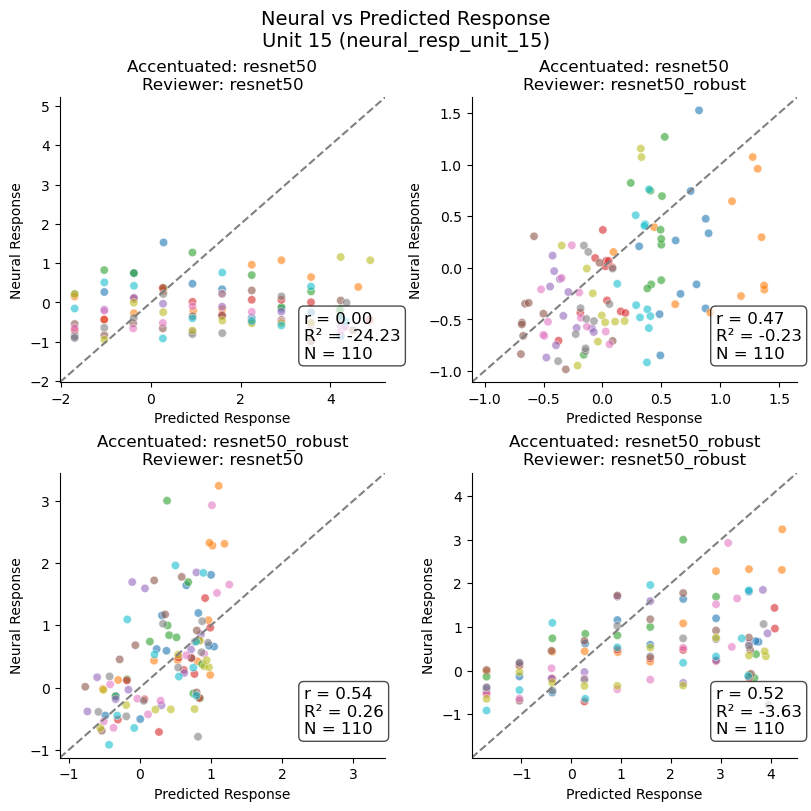

In [91]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
unit_id = 15
yvar = f'neural_resp_unit_{unit_id}'

accentuator_list = ['resnet50', 'resnet50_robust']
reviewer_list = ['resnet50', 'resnet50_robust']

fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
for i, accentuators in enumerate(accentuator_list):
    unit_acc_df = accentuated_merged_df.query("model_name == @accentuators and unit_id == @unit_id")
    for j, reviewer in enumerate(reviewer_list):
        xvar = f'pred_resp_{reviewer}_unit_{unit_id}'
        ax = axes[i, j]
        sns.scatterplot(data=unit_acc_df, y=yvar, x=xvar,
                        hue='img_id', alpha=0.6, palette='tab10', legend=False, ax=ax)
        # Compute correlation and R2, using dropna for fair computation
        x = unit_acc_df[xvar]
        y = unit_acc_df[yvar]
        mask = x.notna() & y.notna()
        if mask.sum() > 1:  # avoid errors in stats
            corr, _ = pearsonr(x[mask], y[mask])
            r2 = r2_score(y[mask], x[mask])
        else:
            corr, r2 = float('nan'), float('nan')
        annot_txt = f"r = {corr:.2f}\nR² = {r2:.2f}\nN = {mask.sum()}"
        # Draw a simple y=x reference line
        curr_xlim = ax.get_xlim()
        curr_ylim = ax.get_ylim()
        min_val = min(curr_xlim[0], curr_ylim[0])
        max_val = max(curr_xlim[1], curr_ylim[1])
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
        ax.text(0.75, 0.25, annot_txt, transform=ax.transAxes, ha='left', va='top',
                fontsize=12, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        ax.set_xlabel('Predicted Response')
        ax.set_ylabel('Neural Response')
        ax.set_title(f'Accentuated: {accentuators}\nReviewer: {reviewer}')
fig.suptitle(f'Neural vs Predicted Response\nUnit {unit_id} ({yvar})', fontsize=14)
saveallforms(FIGDIR, f"acc_peer_review_{subject_id}_U{unit_id}_acc_2x2panel")
plt.show()

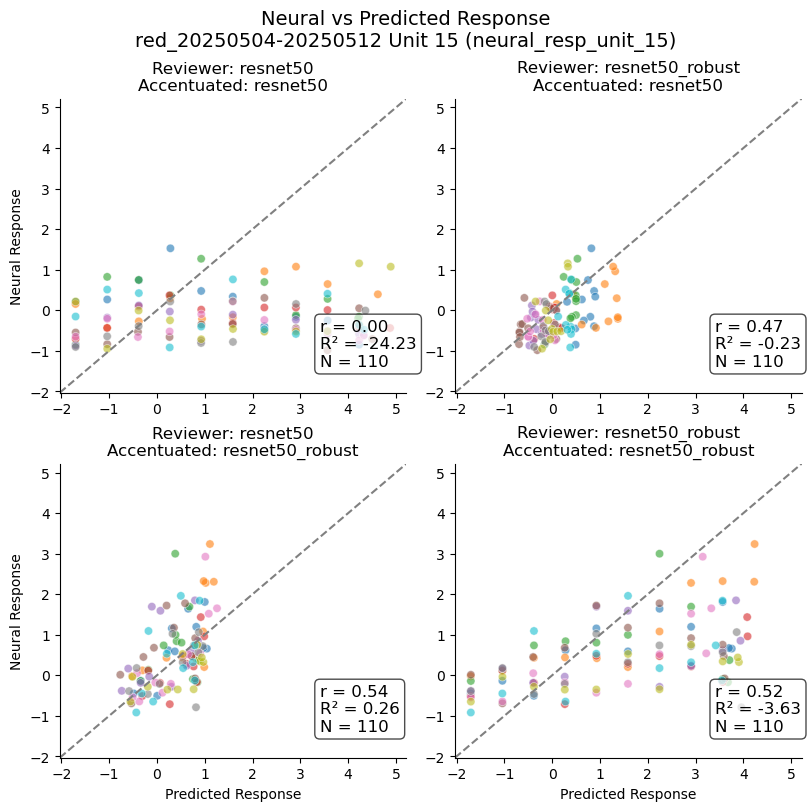

In [98]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
unit_id = 15
yvar = f'neural_resp_unit_{unit_id}'

accentuator_list = ['resnet50', 'resnet50_robust']
reviewer_list = ['resnet50', 'resnet50_robust']

fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True, sharex=True, sharey=True)
for i, accentuators in enumerate(accentuator_list):
    unit_acc_df = accentuated_merged_df.query("model_name == @accentuators and unit_id == @unit_id")
    for j, reviewer in enumerate(reviewer_list):
        xvar = f'pred_resp_{reviewer}_unit_{unit_id}'
        ax = axes[i, j]
        sns.scatterplot(data=unit_acc_df, y=yvar, x=xvar,
                        hue='img_id', alpha=0.6, palette='tab10', legend=False, ax=ax)
        # Compute correlation and R2, using dropna for fair computation
        x = unit_acc_df[xvar]
        y = unit_acc_df[yvar]
        mask = x.notna() & y.notna()
        if mask.sum() > 1:  # avoid errors in stats
            corr, _ = pearsonr(x[mask], y[mask])
            r2 = r2_score(y[mask], x[mask])
        else:
            corr, r2 = float('nan'), float('nan')
        annot_txt = f"r = {corr:.2f}\nR² = {r2:.2f}\nN = {mask.sum()}"
        # Draw a simple y=x reference line
        curr_xlim = ax.get_xlim()
        curr_ylim = ax.get_ylim()
        min_val = min(curr_xlim[0], curr_ylim[0])
        max_val = max(curr_xlim[1], curr_ylim[1])
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
        ax.text(0.75, 0.25, annot_txt, transform=ax.transAxes, ha='left', va='top',
                fontsize=12, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        ax.set_xlabel('Predicted Response')
        ax.set_ylabel('Neural Response')
        ax.set_title(f'Reviewer: {reviewer}\nAccentuated: {accentuators}')
        # Ensure ticks are visible on all sides of each subplot
        ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, )
fig.suptitle(f'Neural vs Predicted Response\n{subject_id} Unit {unit_id} ({yvar})', fontsize=14)
saveallforms(FIGDIR, f"acc_peer_review_{subject_id}_U{unit_id}_acc_2x2panel")
plt.show()

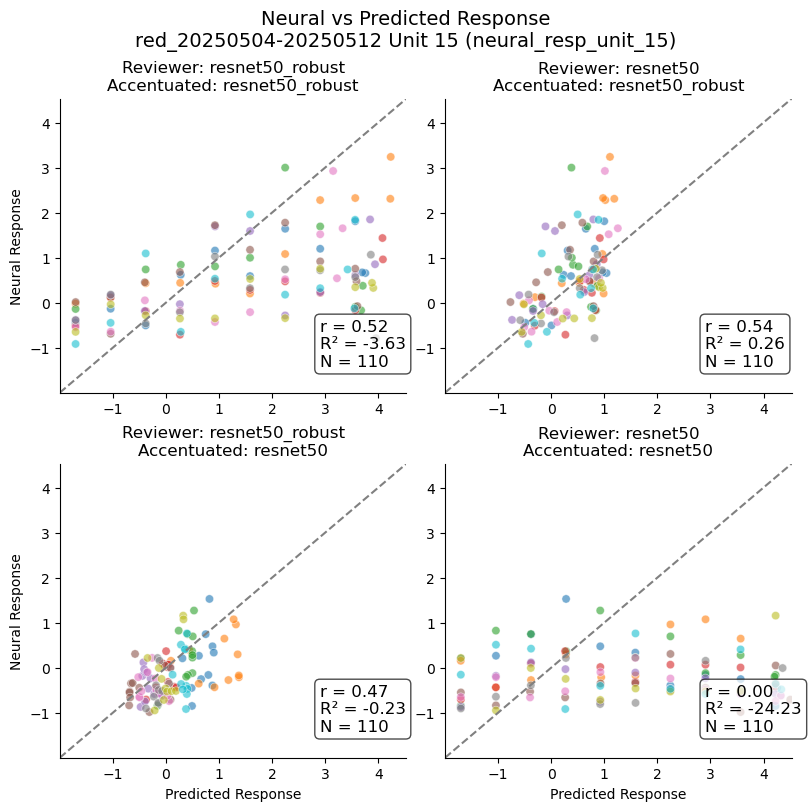

In [97]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
unit_id = 15
yvar = f'neural_resp_unit_{unit_id}'

accentuator_list = ['resnet50_robust', 'resnet50', ]
reviewer_list = ['resnet50_robust', 'resnet50', ]

fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True, sharex=True, sharey=True)
for i, accentuators in enumerate(accentuator_list):
    unit_acc_df = accentuated_merged_df.query("model_name == @accentuators and unit_id == @unit_id")
    for j, reviewer in enumerate(reviewer_list):
        xvar = f'pred_resp_{reviewer}_unit_{unit_id}'
        ax = axes[i, j]
        sns.scatterplot(data=unit_acc_df, y=yvar, x=xvar,
                        hue='img_id', alpha=0.6, palette='tab10', legend=False, ax=ax)
        # Compute correlation and R2, using dropna for fair computation
        x = unit_acc_df[xvar]
        y = unit_acc_df[yvar]
        mask = x.notna() & y.notna()
        if mask.sum() > 1:  # avoid errors in stats
            corr, _ = pearsonr(x[mask], y[mask])
            r2 = r2_score(y[mask], x[mask])
        else:
            corr, r2 = float('nan'), float('nan')
        annot_txt = f"r = {corr:.2f}\nR² = {r2:.2f}\nN = {mask.sum()}"
        # Draw a simple y=x reference line
        curr_xlim = ax.get_xlim()
        curr_ylim = ax.get_ylim()
        min_val = min(curr_xlim[0], curr_ylim[0])
        max_val = max(curr_xlim[1], curr_ylim[1])
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.axline((0, 0), slope=1, linestyle='--', color='gray', label='y = x')
        ax.text(0.75, 0.25, annot_txt, transform=ax.transAxes, ha='left', va='top',
                fontsize=12, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        ax.set_xlabel('Predicted Response')
        ax.set_ylabel('Neural Response')
        ax.set_title(f'Reviewer: {reviewer}\nAccentuated: {accentuators}')
        # Ensure ticks are visible on all sides of each subplot
        ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, )
fig.suptitle(f'Neural vs Predicted Response\n{subject_id} Unit {unit_id} ({yvar})', fontsize=14)
saveallforms(FIGDIR, f"acc_peer_review_{subject_id}_U{unit_id}_acc_2x2panel_rev_order")
plt.show()